# 0. Initialization 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
import os
from scipy.signal import welch, find_peaks

%matplotlib inline

# 1. Load data

In [2]:
data_dir = Path("./data")  
npz_dir = data_dir / "configs"
output_dir_svg = Path("./out/svg") 
output_dir_pdf = Path("./out/pdf") 
output_dir_svg.mkdir(parents=True, exist_ok=True)
output_dir_pdf.mkdir(parents=True, exist_ok=True)


In [46]:
npz_files = sorted(npz_dir.glob("*.npz"))

# generate labels from file names
# labels = [f.stem.replace('_', ' + ') for f in npz_files]


# runs of ~180s at ~40 fps by data  
runs = 5


exp_data = [{'raw_data': np.load(f, allow_pickle=True), 
             'label': f.stem.replace('_', ' + '), 
             'data': {}}  
                for f in npz_files]

new_order = [2,0,1,3,4,5]

exp_data = [exp_data[i] for i in new_order]

for data in exp_data:
    data['data']['runs'] = []
    for run in range(1, runs+1):
        data_run = {}
        data_run['phi'] = data['raw_data'][f"phi_t_run{run}"]
        data_run['phi'] -= np.mean(data_run['phi'])
        data_run['fps'] = data['raw_data'][f"fps{run}"]
        data_run['duration'] = data['raw_data'][f"duree{run}"]
        data['data']['runs'].append(data_run)


[e['label'] for e in exp_data]
    

['Mirror',
 'Custom  mount + Foam',
 'Custom mount',
 'ViALUX mount',
 'ViALUX mount + LS',
 'ViALUX mount + LS + Foam']

In [47]:
img_data = np.load(data_dir / "tuto_vialux.npz", allow_pickle=True)
images = img_data['images']

## 2. Plot images of the fringes used for phase extraction

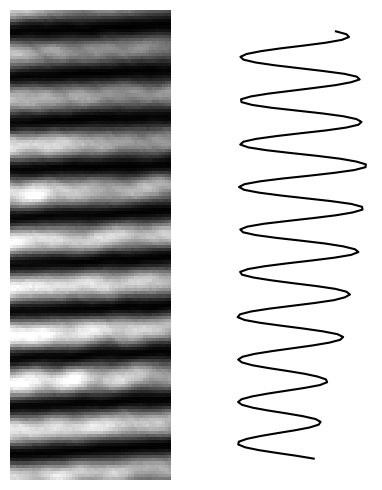

In [48]:
fringes_2D = images[0]
fringes_1D = np.sum(fringes_2D, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 5), gridspec_kw={'width_ratios': [4, 1.5]})

ax1.imshow(fringes_2D, cmap='gray')
ax1.axis('off')

ax2.plot(fringes_1D, np.arange(len(fringes_1D)), 'k-')
ax2.axis('off')

plt.tight_layout()
plt.savefig(output_dir_svg / "example_fringes.svg")
plt.savefig(output_dir_pdf / "example_fringes.pdf")


# 3. Standard deviation study

In [49]:
def plot_phi(ax, data_run):
    yticks = np.linspace(-np.pi / 4, np.pi / 4, 3)
    ylabels = [ r'$-\pi/4$', r'$0$', r'$\pi/4$'] 
    
    phi = data_run['phi']
    fps = data_run['fps']
    duree = data_run['duration']

    N = round(fps * duree)
    t_uniform = np.arange(N) / fps

    
    std = np.std(phi)

    ax.plot(t_uniform, phi / np.pi, '-k')
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)
    ax.set_title(
        f'Acquisition {run} | fps={fps:.2f} | duration={duree:.1f}s | std={std:.3f}'
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Phase')

    return std


## 3.1 Plot the temporal measurements of the phase for 5 runs for each setup condition

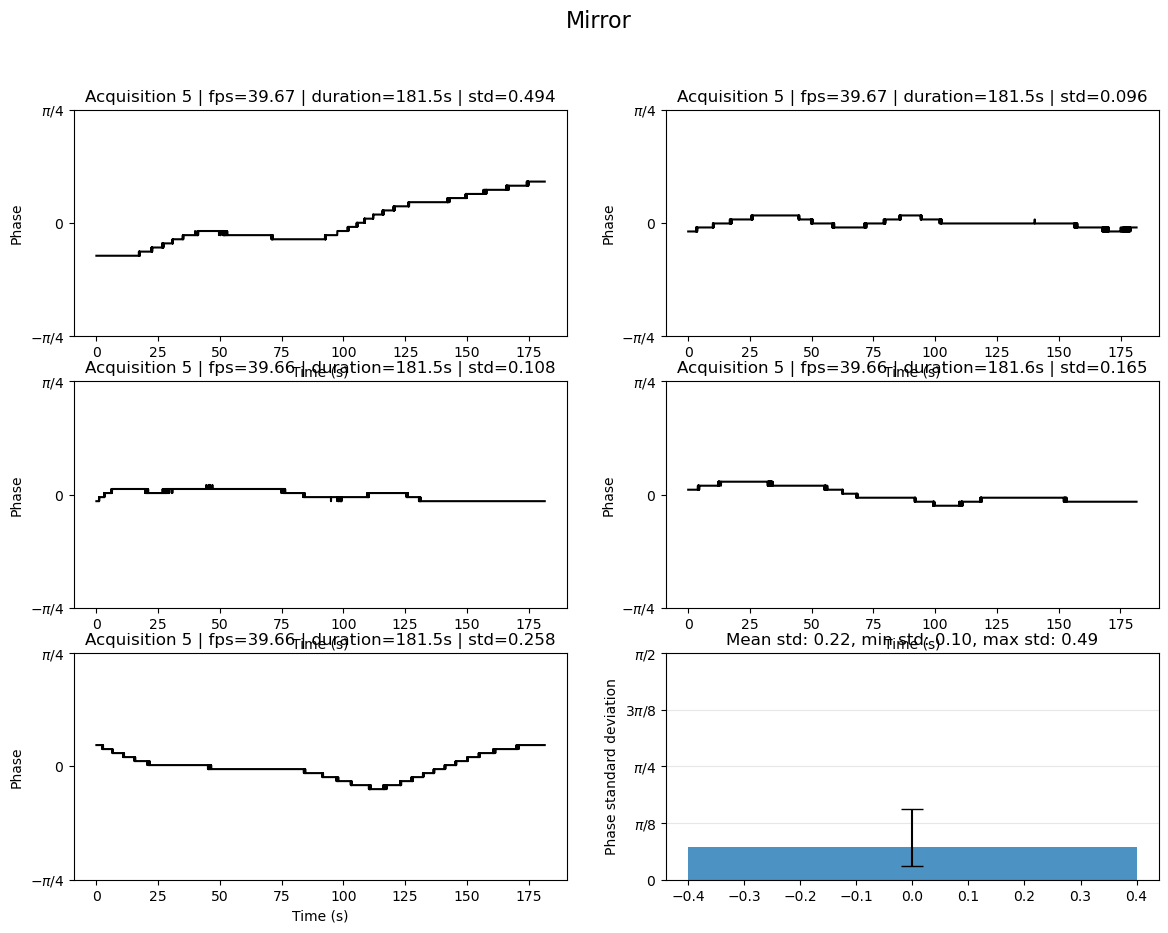

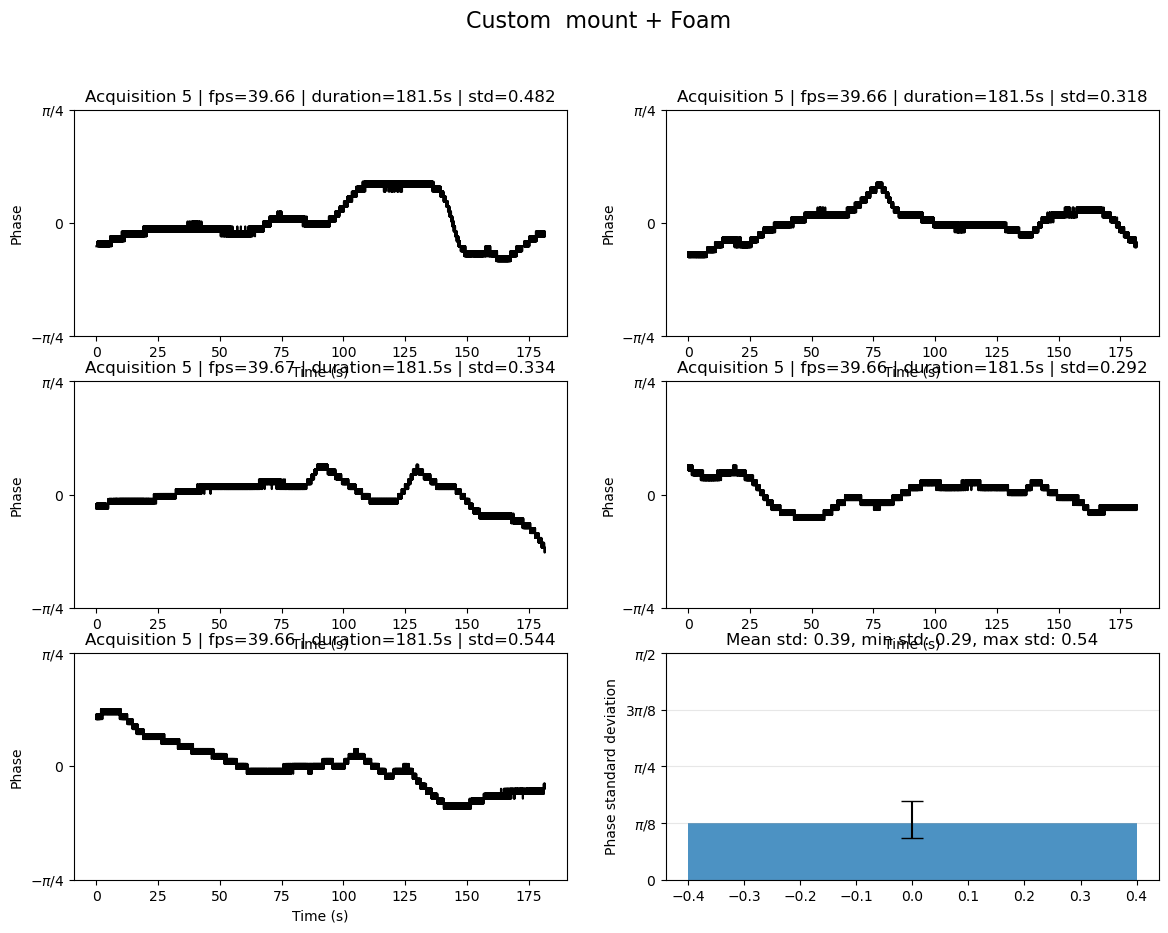

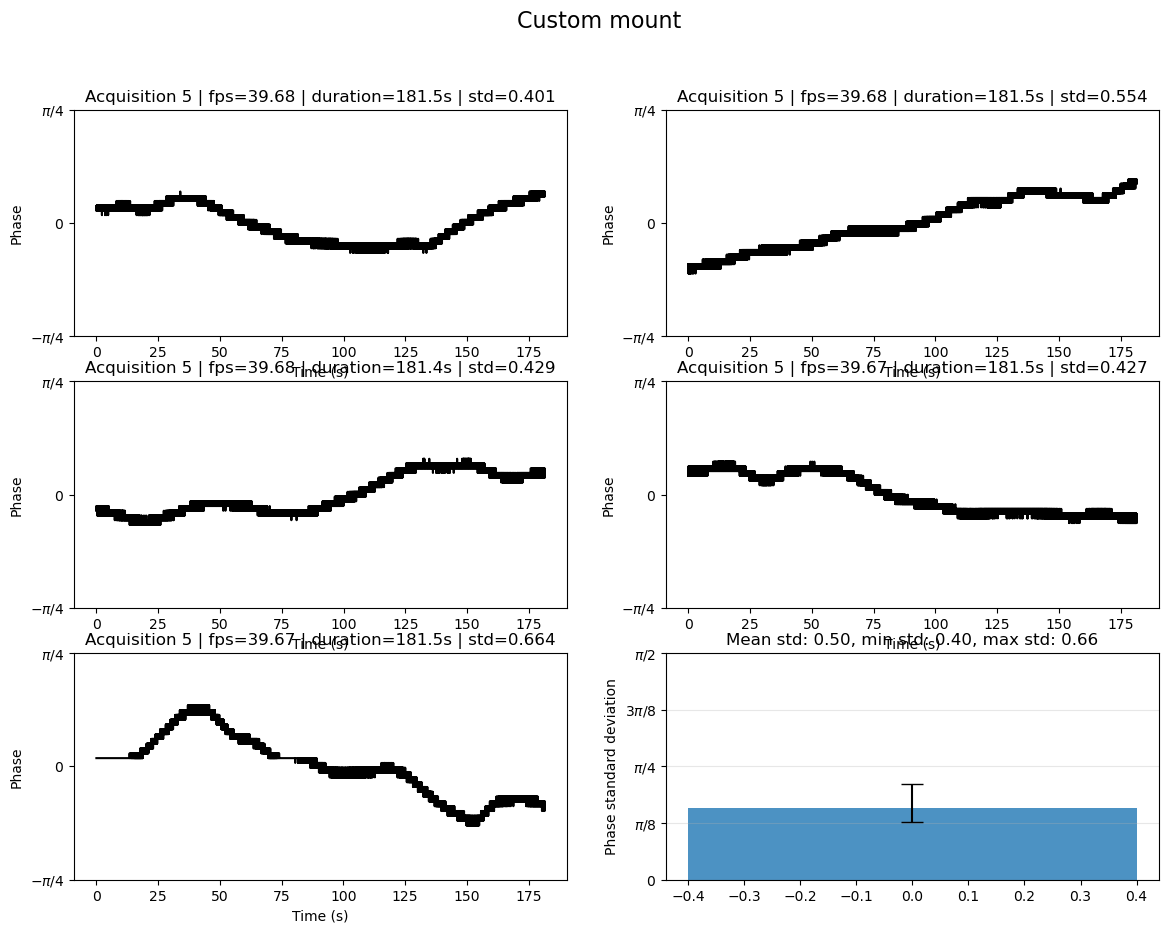

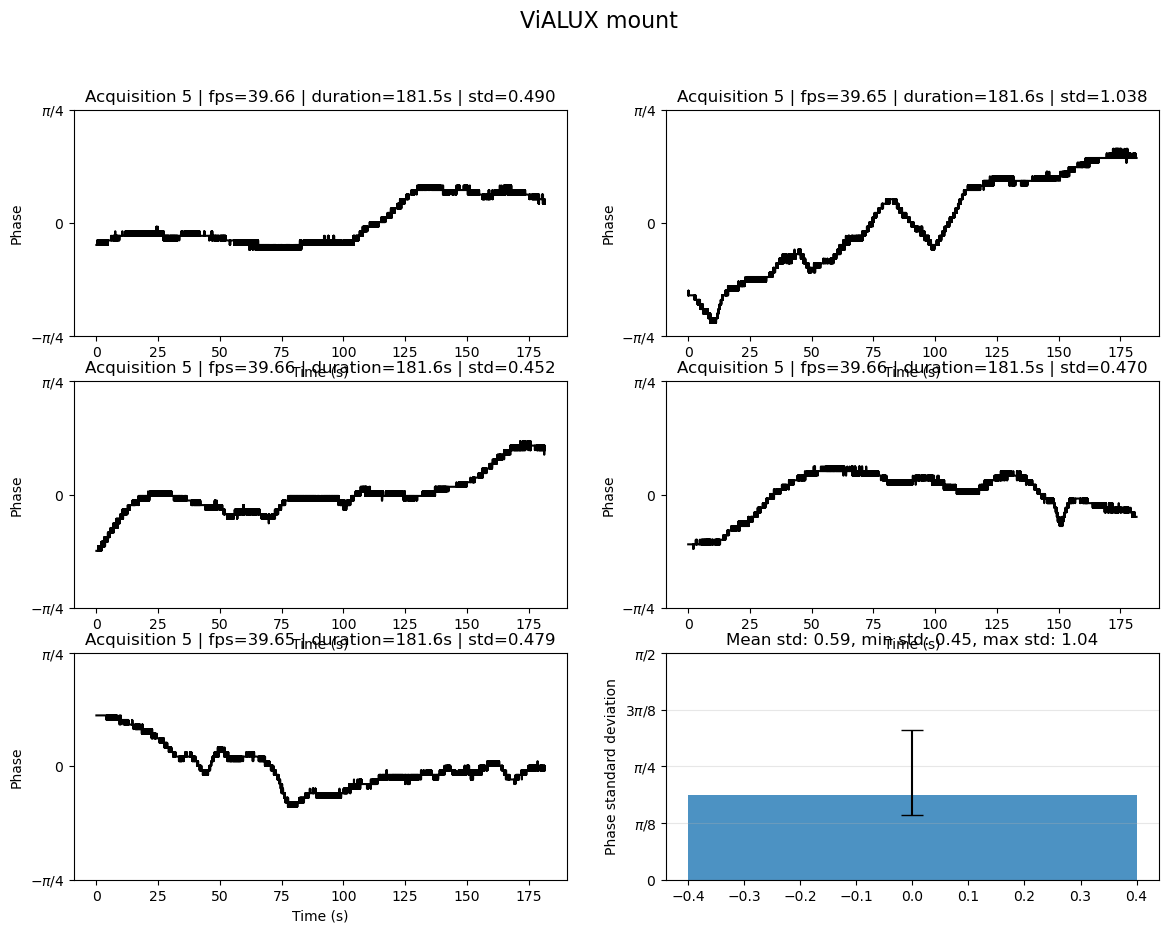

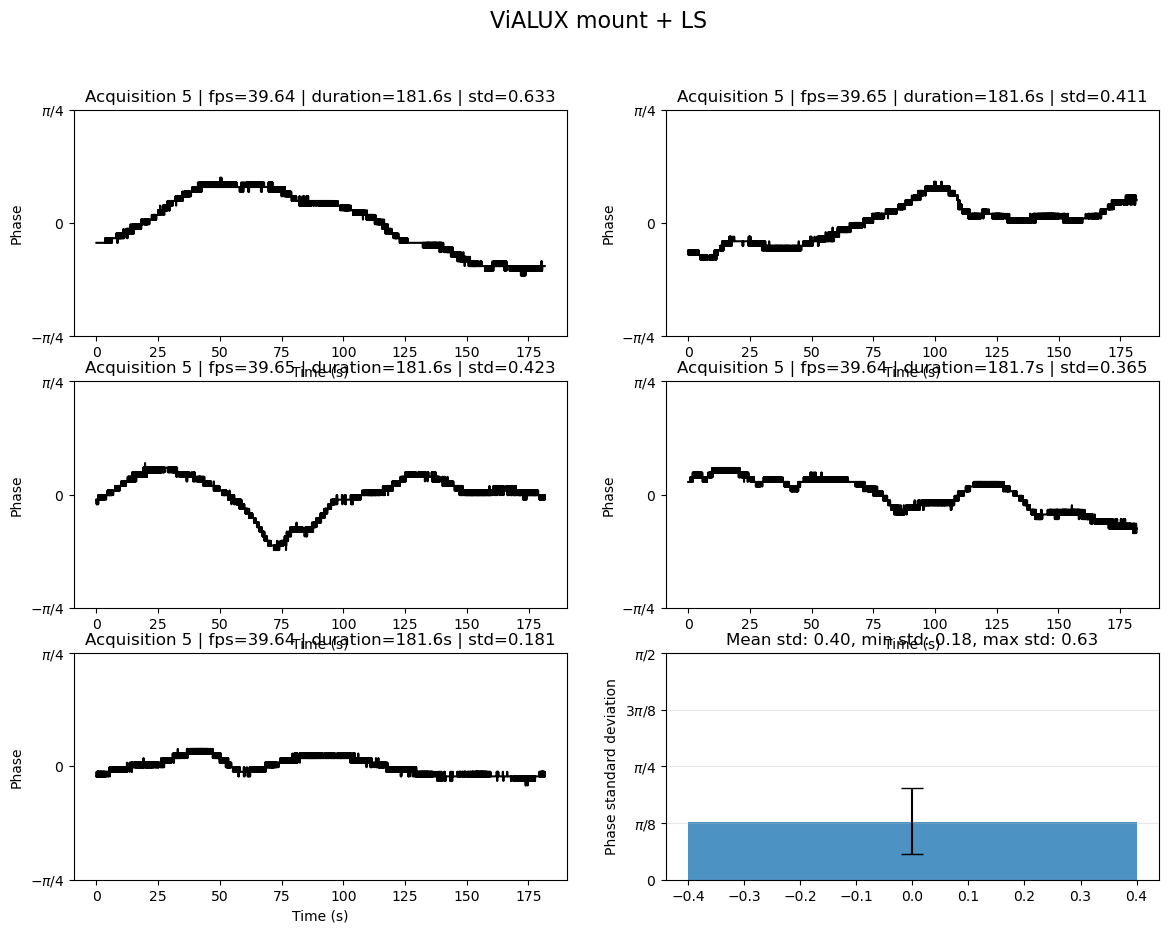

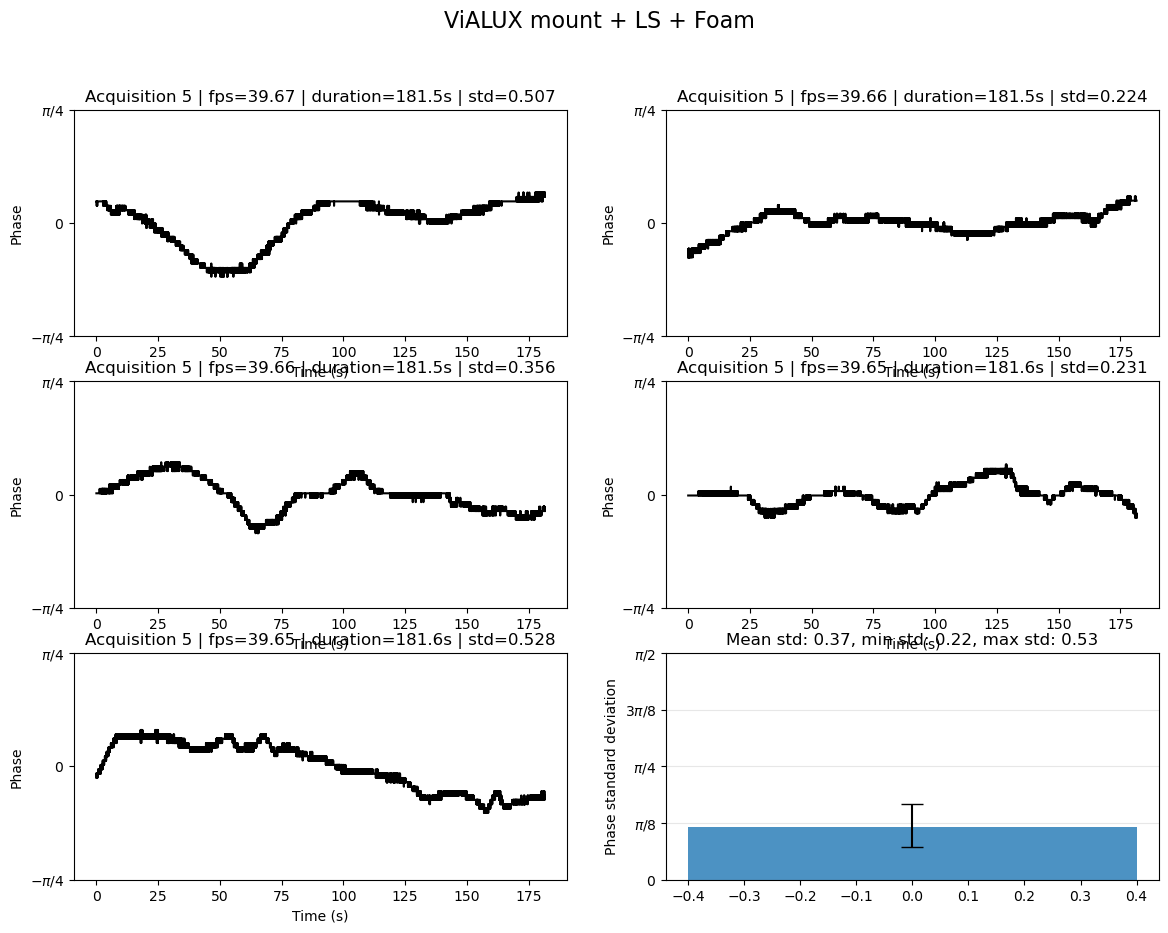

In [50]:
def plot_temp_stats(data, title):


    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle(f'{title}', fontsize=16)
    axes = axes.ravel()



    # ---------- runs ----------
    std_list = []
    for i, data_run in enumerate(data['runs']):
        std = plot_phi(axes[i],data_run)
        std_list.append(std)

    # ---------- statistics ----------
    std_mean = np.mean(std_list)
    std_min = np.min(std_list)
    std_max = np.max(std_list)

    # ---------- 6th subplot ----------
    ax = axes[5]

    x = [0]

    yerr = [
        [(std_mean - std_min) / np.pi],
        [(std_max - std_mean) / np.pi]
    ]

    ax.bar(
        x,
        [std_mean / np.pi],
        yerr=yerr,
        capsize=8,
        alpha=0.8,
        color='tab:blue'
    )

    ax.set_yticks(
        [0, 0.125, 0.25, 0.375, 0.5]
    )
    ax.set_yticklabels(
        [r'$0$', r'$\pi/8$', r'$\pi/4$', r'$3\pi/8$', r'$\pi/2$']
    )

    ax.set_ylim([0, 0.5])
    ax.set_ylabel("Phase standard deviation")
    ax.set_title(
        f"Mean std: {std_mean:.2f}, min std: {std_min:.2f}, max std: {std_max:.2f}"
    )
    ax.grid(axis="y", alpha=0.3)

    # plt.tight_layout()
    # save_fig("ViALUX_LS_Foam", output_dir_svg, output_dir_pdf)
    plt.show()


for data in exp_data:
    plot_temp_stats(data['data'], data['label'])

## 3.2 Plot standard deviations

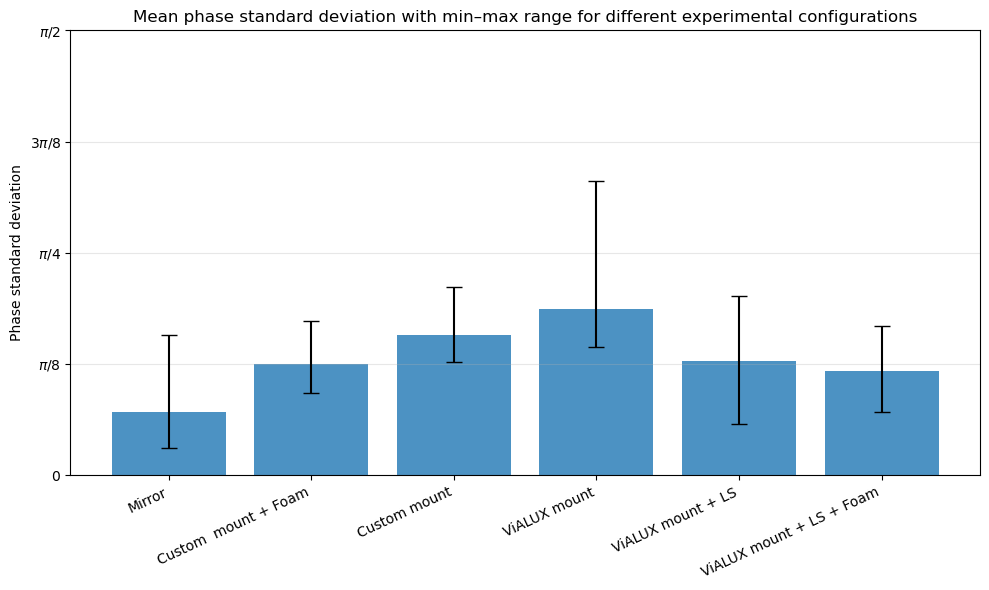

In [51]:


mean_list = []
min_list = []
max_list = []

for data in exp_data:

    std_list = []
    for data_run in data['data']['runs']:
        phi = data_run['phi']
        std_list.append(np.std(phi))

    mean_list.append(np.mean(std_list))
    min_list.append(np.min(std_list))
    max_list.append(np.max(std_list))

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(mean_list))

y = np.array(mean_list) 
yerr = np.array([
    (np.array(mean_list) - np.array(min_list)),
    (np.array(max_list) - np.array(mean_list))
])

ax.bar(
    x,
    y,
    yerr=yerr,
    capsize=6,
    alpha=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(
    [data['label'] for data in exp_data],
    rotation=25,
    ha="right"
)

ax.set_ylabel("Phase standard deviation")
ax.set_yticks(np.linspace(0, np.pi/2, 5))
ax.set_yticklabels([r"$0$", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])
ax.set_ylim(0, np.pi/2)

ax.set_title(
    "Mean phase standard deviation with min–max range for different experimental configurations"
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir_svg / "summary_stats.svg")
plt.savefig(output_dir_pdf / "summary_stats.pdf")


## 4. Frequency Domain Analysis

In [52]:

def mean_psd(data):
    """Compute the mean PSD over all runs using Welch's method."""
    Pxx_all = []

    for data_run in data['runs']:
        # Remove DC offset (mean phase)
        phi = data_run['phi'] - np.mean(data_run['phi'])
        Fe = data_run['fps']  # sampling frequency

        # Estimate PSD with Welch's method (segment length = 4096 samples)
        f, Pxx = welch(
            phi,
            fs=Fe,
            window="hann",
            nperseg=4096,
            detrend="constant"  # remove residual DC within each segment
        )
        Pxx_all.append(Pxx)

    # Average PSDs across runs to reduce noise
    return f, np.mean(Pxx_all, axis=0)


def log_smooth_psd(f, Pxx, n_bins=80):
    logf = np.log10(f)
    bins = np.linspace(logf.min(), logf.max(), n_bins + 1)

    f_s, Pxx_s = [], []
    for i in range(n_bins):
        mask = (logf >= bins[i]) & (logf < bins[i + 1])
        if np.any(mask):
            f_s.append(np.exp(np.mean(np.log(f[mask]))))
            Pxx_s.append(np.mean(Pxx[mask]))

    return np.array(f_s), np.array(Pxx_s)

Text(0.5, 0, 'Frequency (Hz)')

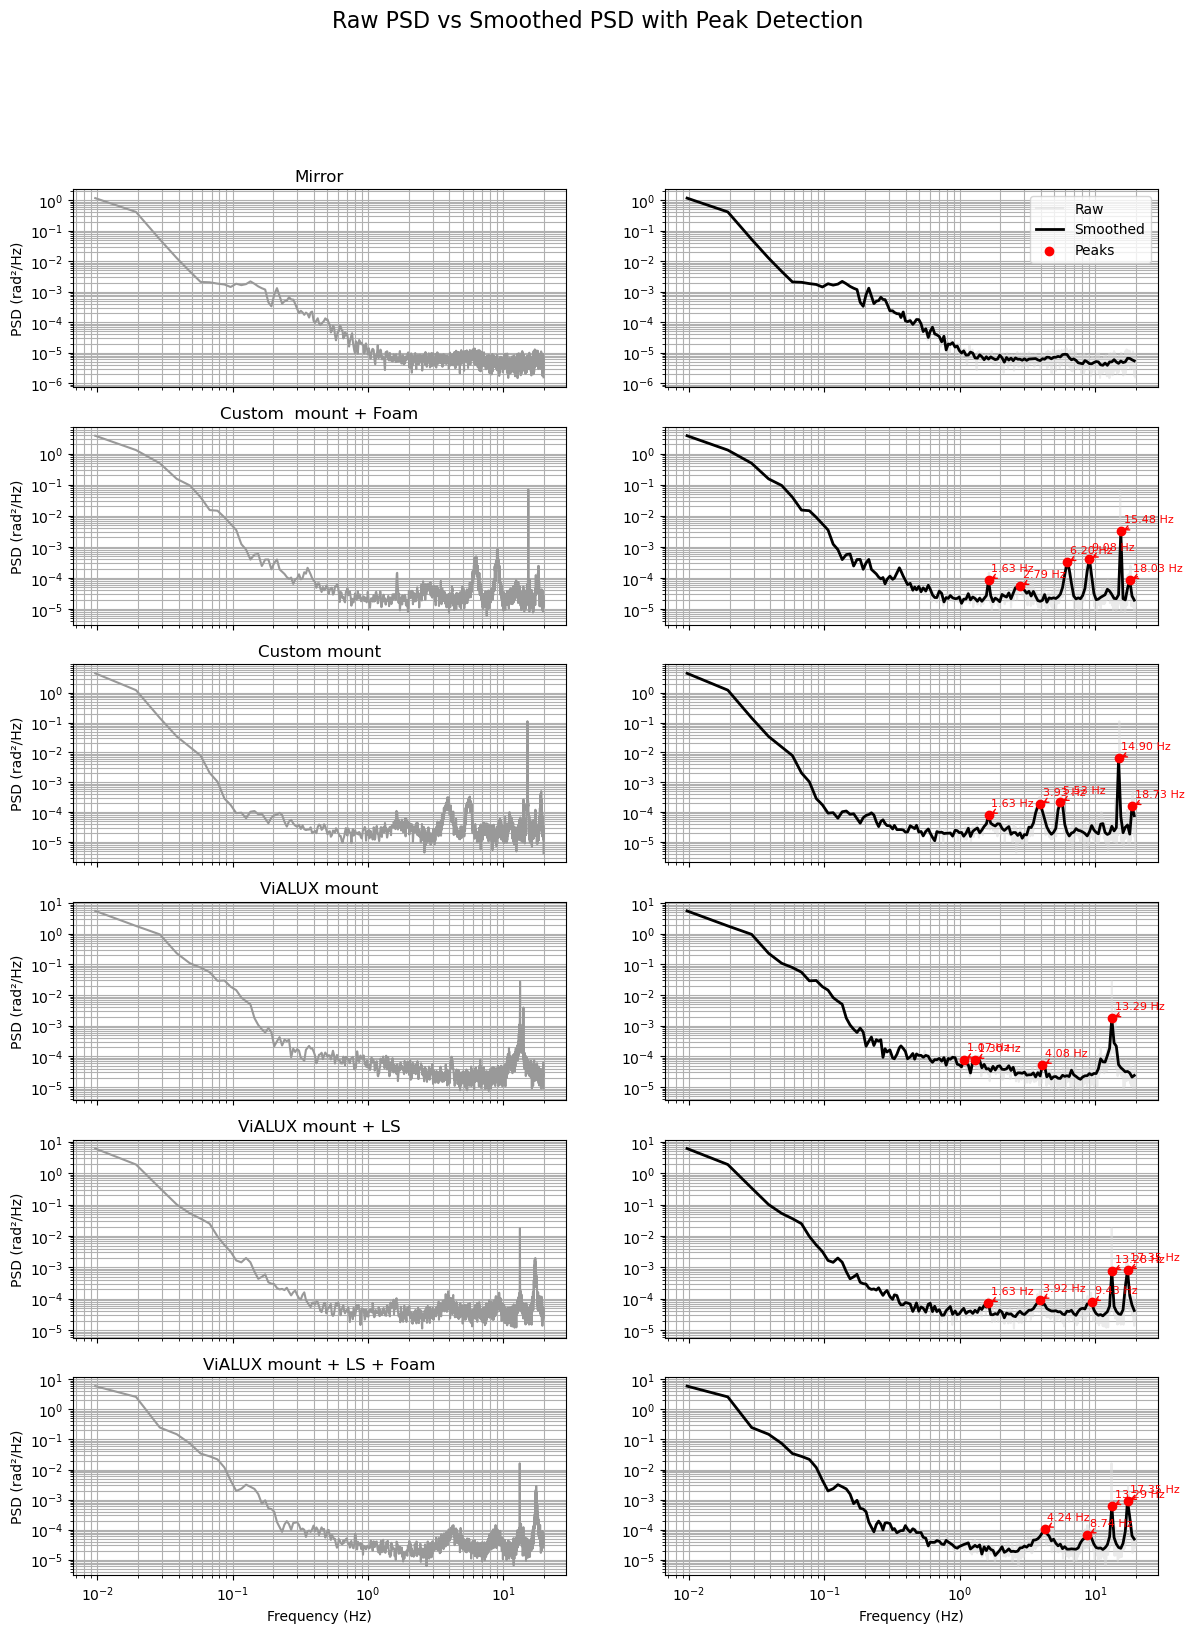

In [53]:
f_min = 1.0
power_min = 2e-5
prominence = 3e-5
n_bins = 200
# plt.figure()
# ======================================================
# FIGURE 1 — RAW PSD vs SMOOTHED PSD (6 × 2)
# ======================================================
fig, axes = plt.subplots(
    6, 2,
    figsize=(14, 18),
    sharex="col"
)

fig.suptitle(
    "Raw PSD vs Smoothed PSD with Peak Detection",
    fontsize=16
)

# Storage of peaks for Figure 2
all_peaks = {}

# for i, (name, data) in enumerate(configs):
for i, d in enumerate(exp_data):
    name = d['label']
    data = d['data']

    # ---------- Mean PSD ----------
    f_psd, Pxx = mean_psd(data)

    # Remove f = 0
    mask_pos = f_psd > 0
    f_psd = f_psd[mask_pos]
    Pxx = Pxx[mask_pos]

    # ---------- Smoothing ----------
    f_s, Pxx_s = log_smooth_psd(f_psd, Pxx, n_bins=n_bins)

    # ---------- Peak Detection ----------
    peaks, _ = find_peaks(Pxx_s, prominence=prominence)

    f_peaks = f_s[peaks]
    Pxx_peaks = Pxx_s[peaks]

    # Keep only valid peaks
    valid = (f_peaks > f_min) & (Pxx_peaks > power_min)
    f_peaks = f_peaks[valid]
    Pxx_peaks = Pxx_peaks[valid]

    # Interpolate raw PSD at detected peak frequencies
    Pxx_peaks_raw = np.interp(f_peaks, f_psd, Pxx)

    all_peaks[name] = (f_peaks, Pxx_peaks_raw)

    # ---------- COLUMN 1: Raw PSD ----------
    axes[i, 0].loglog(f_psd, Pxx, color="0.6")
    axes[i, 0].set_ylabel("PSD (rad²/Hz)")
    axes[i, 0].set_title(name)
    axes[i, 0].grid(which="both")

    # ---------- COLUMN 2: Smoothed PSD + Peaks ----------
    axes[i, 1].loglog(f_psd, Pxx, color="0.85", alpha=0.5, label="Raw")
    axes[i, 1].loglog(f_s, Pxx_s, "k", lw=2, label="Smoothed")

    axes[i, 1].scatter(
        f_peaks,
        Pxx_peaks,
        color="red",
        zorder=5,
        label="Peaks" if i == 0 else None
    )

    # Annotate peaks
    for f_p, P_p in zip(f_peaks, Pxx_peaks):
        axes[i, 1].annotate(
            f"{f_p:.2f} Hz",
            xy=(f_p, P_p),
            xytext=(f_p * 1.05, P_p * 2),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=8,
            color="red"
        )

    axes[i, 1].grid(which="both")

    if i == 0:
        axes[i, 1].legend()

axes[-1, 0].set_xlabel("Frequency (Hz)")
axes[-1, 1].set_xlabel("Frequency (Hz)")


# plt.tight_layout(rect=[0, 0, 1, 0.96])
# # save_fig("SpecWithPeaks", output_dir_svg, output_dir_pdf)
# # plt.show()



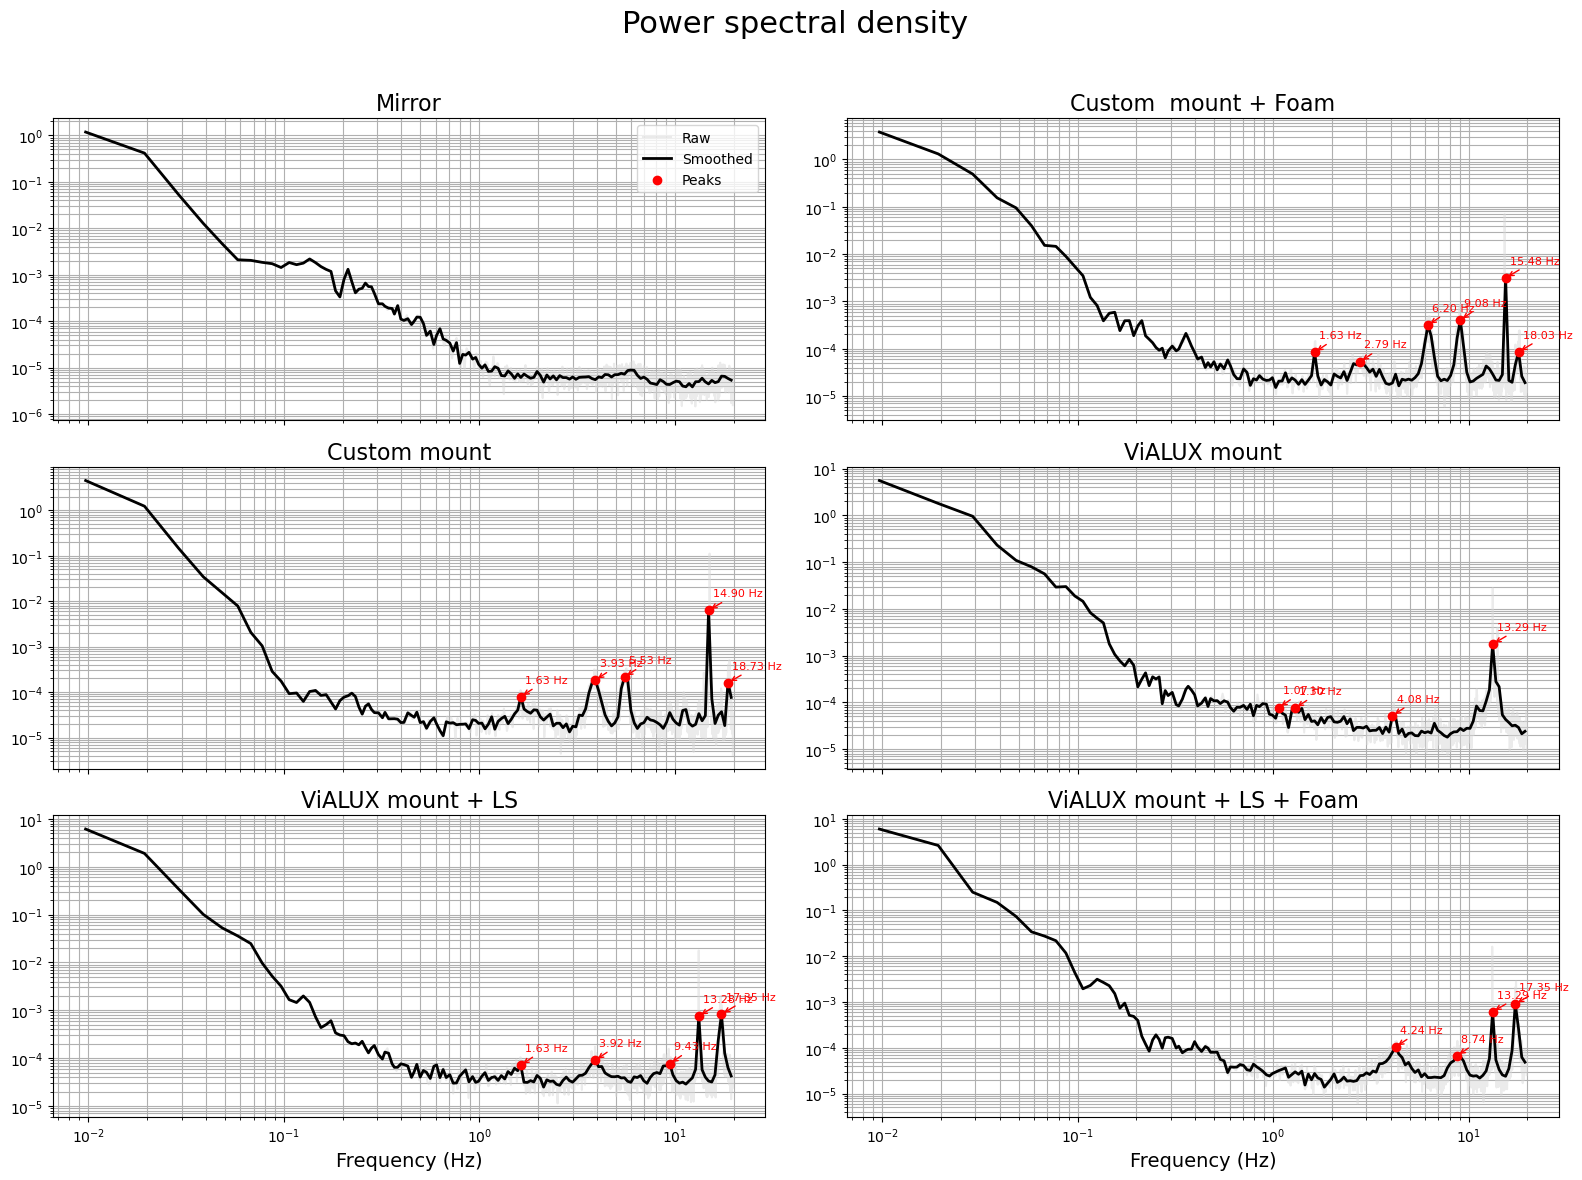

In [56]:

# plt.figure()
# ======================================================
# FIGURE 1 — RAW PSD vs SMOOTHED PSD (6 × 2)
# ======================================================
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12),
    sharex="col"
)

fig.suptitle(
    "Power spectral density",
    fontsize=22
)

# Storage of peaks for Figure 2
all_peaks = {}

# for i, (name, data) in enumerate(configs):
for i, d in enumerate(exp_data):
    name = d['label']
    data = d['data']

    # ---------- Mean PSD ----------
    f_psd, Pxx = mean_psd(data)

    # Remove f = 0
    mask_pos = f_psd > 0
    f_psd = f_psd[mask_pos]
    Pxx = Pxx[mask_pos]

    # ---------- Smoothing ----------
    f_s, Pxx_s = log_smooth_psd(f_psd, Pxx, n_bins=n_bins)

    # ---------- Peak Detection ----------
    peaks, _ = find_peaks(Pxx_s, prominence=prominence)

    f_peaks = f_s[peaks]
    Pxx_peaks = Pxx_s[peaks]

    # Keep only valid peaks
    valid = (f_peaks > f_min) & (Pxx_peaks > power_min)
    f_peaks = f_peaks[valid]
    Pxx_peaks = Pxx_peaks[valid]

    # Interpolate raw PSD at detected peak frequencies
    Pxx_peaks_raw = np.interp(f_peaks, f_psd, Pxx)

    all_peaks[name] = (f_peaks, Pxx_peaks_raw)




    axes.flatten()[i].loglog(f_psd, Pxx, color="0.85", alpha=0.5, label="Raw")
    axes.flatten()[i].loglog(f_s, Pxx_s, "k", lw=2, label="Smoothed")

    axes.flatten()[i].scatter(
        f_peaks,
        Pxx_peaks,
        color="red",
        zorder=5,
        label="Peaks" if i == 0 else None
    )

    # Annotate peaks
    for f_p, P_p in zip(f_peaks, Pxx_peaks):
        axes.flatten()[i].annotate(
            f"{f_p:.2f} Hz",
            xy=(f_p, P_p),
            xytext=(f_p * 1.05, P_p * 2),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=8,
            color="red"
        )

    axes.flatten()[i].grid(which="both")
    axes.flatten()[i].set_title(name, fontsize = 16)

    if i == 0:
        axes.flatten()[i].legend()

axes.flatten()[-2].set_xlabel("Frequency (Hz)", fontsize = 14)
axes.flatten()[-1].set_xlabel("Frequency (Hz)", fontsize = 14)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(output_dir_svg / "SpecWithPeaks.svg")
plt.savefig(output_dir_pdf / "SpecWithPeaks.pdf")
